C:\Users\ygunj\AppData\Local\Temp\ipykernel_27024\3741866652.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


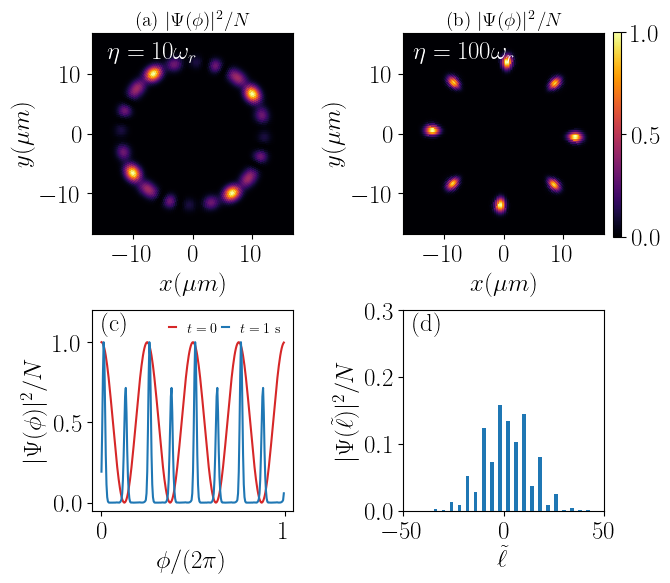

In [4]:
import numpy as np
import os

save_file = r"Figure_18_data.npz"
data = np.load(save_file)

X = data["X"]
Y = data["Y"]

ring10 = data["ring10"]
ring100 = data["ring100"]

phi = data["phi"]
dens_t0 = data["dens_t0"]
dens_tmid = data["dens_tmid"]

l_vals = data["l_vals"]
pop_final = data["pop_final"]

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------
# LaTeX style (paper-ready)
# ------------------------------------------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 14,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

vmax = 1.0

# ============================================================
# Figure layout
# ============================================================
fig = plt.figure(figsize=(8.2, 6.2))
gs = GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.05],
    height_ratios=[1, 1],
    wspace=0.25,
    hspace=0.38
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
cax = fig.add_subplot(gs[:, 2])

# ============================================================
# (a) eta = 10 wr
# ============================================================
im1 = ax1.pcolormesh(
    X * 1e6,
    Y * 1e6,
    ring10,
    cmap="inferno",
    shading="auto",
    vmin=0,
    vmax=vmax
)

ax1.set_aspect("equal")
ax1.set_xlabel(r"$x(\mu m)$")
ax1.set_ylabel(r"$y(\mu m)$")
ax1.text(
    0.3, 0.96,
    r"$\eta = 10\omega_r$",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    color="white"
)
ax1.set_title(r"(a) $|\Psi(\phi)|^2/N$", fontweight="bold")

# ============================================================
# (b) eta = 100 wr
# ============================================================
im2 = ax2.pcolormesh(
    X * 1e6,
    Y * 1e6,
    ring100,
    cmap="inferno",
    shading="auto",
    vmin=0,
    vmax=vmax
)

ax2.set_aspect("equal")
ax2.set_xlabel(r"$x(\mu m)$")
ax2.set_ylabel(r"$y(\mu m)$")
ax2.text(
    0.3, 0.96,
    r"$\eta = 100\omega_r$",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    color="white"
)
ax2.set_title(r"(b) $|\Psi(\phi)|^2/N$", fontweight="bold")

# ============================================================
# Shared colorbar
# ============================================================
cbar = fig.colorbar(im2, cax=cax)

# shrink manually: [left, bottom, width, height]
cax.set_position([0.8, 0.552, 0.01, 0.33])
cbar.set_ticks([0, 0.5, 1])
# ============================================================
# (c) density evolution
# ============================================================
ax3.plot(phi/(2*np.pi), dens_t0, lw=1.5, color="C3", label=r"$t=0$")
ax3.plot(phi/(2*np.pi), dens_tmid, lw=1.5, color="C0", label=r"$t=1$ s")

ax3.set_xlabel(r"$\phi/(2\pi)$")
ax3.set_ylabel(r"$|\Psi(\phi)|^2/N$")
ax3.set_ylim([-0.05, 1.2])
ax3.legend(frameon=False, fontsize=10, ncol=2,  columnspacing=0.3,handlelength=0.5)
ax3.text(0.05, 0.9, "(c)", transform=ax3.transAxes, fontweight="bold")

# ============================================================
# (d) angular momentum spectrum
# ============================================================
ax4.bar(l_vals, pop_final, width=1.8)
ax4.set_xlim([-50, 50])
ax4.set_ylim([0, 0.3])
ax4.set_xlabel(r"$\tilde{\ell}$")
ax4.set_ylabel(r"$|\Psi(\tilde{\ell})|^2/N$")
ax4.text(0.05, 0.9, "(d)", transform=ax4.transAxes, fontweight="bold")

# ============================================================
# Square panels
# ============================================================
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_box_aspect(1)

plt.tight_layout()
plt.show()